In [1]:
import numpy as np
import scipy as sp
import pickle
import os
import matplotlib.pyplot as plt



In [2]:
def sort_dataset_by_mean_abundance(full_dataset,family_tags,which_mean='when_present',
                                  return_argsort = False,
                                  entropies=None):
    '''
    Data is normalized into relative abundances at the end, just in case.
    '''
    means = np.mean(full_dataset,axis=0)
    above_threshold = (full_dataset>means[None,:])
    times_above_threshold = np.sum(above_threshold,axis=0)
    new_means = np.sum(full_dataset*above_threshold, #take mean only of the data where the samples are above their mean value.
                        axis=0)/times_above_threshold
    times_present = np.sum(full_dataset>0,axis=0)
    
    maxes = np.max(full_dataset,axis=0) #maximum relative abundance of each species
    ''' Sort using total mean or mean when present (new_means) '''
    if which_mean=='when_present':
        print('Sorting by mean when present')
        indices_by_mean_abundance = np.flip(np.argsort(new_means))
    elif which_mean=='maxes':
        print('Sorting by maximum value')
        indices_by_mean_abundance = np.flip(np.argsort(maxes))
    elif which_mean=='means':
        print('Sorting by mean (both present and absent)')
        indices_by_mean_abundance = np.flip(np.argsort(means))
    elif which_mean=='number_appearances':
        print('Sorting by number of appearances')
        indices_by_mean_abundance = np.flip(np.argsort(times_present))
    elif which_mean=='entropies':
        print('Sorting by entropy')
        indices_by_mean_abundance = np.flip(np.argsort(entropies))
    else:
        print('No proper sorting preference given')
    
    full_dataset = full_dataset[:,indices_by_mean_abundance]
    family_tags = [family_tags[tag] for tag in indices_by_mean_abundance]
    
    # full_dataset =full_dataset/np.sum(full_dataset,axis=1)[:,None] #renormalize back to 1 just in case, even if it should be supefluous.
    print('Most common strains: \n',family_tags[:6])
    
    how_many_experimental_samples,how_many_species = np.shape(full_dataset)

    if return_argsort ==True:
        output = (full_dataset,family_tags,how_many_experimental_samples,how_many_species,indices_by_mean_abundance)
    else:
        output = (full_dataset,family_tags,how_many_experimental_samples,how_many_species)
    return output

In [3]:
''' Calculate the Shannon Entropy for the marginal distribution of each species, then select which species to keep as those
that have the highest entropy. 

Species with low entropy in their marginal distribution are likely to be species that most of the time have a low abundance and rarely have a 
very high abundance, so we wanna rule them out. '''

from scipy.stats import entropy as shannon_entropy

def calculate_shannon_entropies(full_dataset_copy,
                               z_scores = True):

    full_dataset = np.copy(full_dataset_copy)

    ''' Set 0s in the dataset as abundances 2 orders of mangitude below the minimum non-zero abundance in the dataset 
    This makes 0s appear in the distribution, and ensures that the peak of absences is counted towards the entropy of the distribution.
    '''
    min_dataset = np.min(full_dataset[full_dataset>0])
    bin_min = np.log10(min_dataset)-2
    full_dataset[full_dataset==0] = 10**bin_min

    ''' If z_scores == True,
    rescaled abundances as y---> z = (y-mean(y))/std(y), where y=log10(x) 
    such that we calculate the entropy of a taxon's AFD and consider its distribution of rescaled abundance changes, independently of whether it 
    is an overall high- or low-abundance species.
    '''
    full_dataset = np.log10(full_dataset)
    if z_scores ==True:
        means = np.mean(full_dataset,axis=0)[None,:]
        stds = np.std(full_dataset,axis=0)[None,:]
        full_dataset = (full_dataset-means)/stds
    full_dataset = 10**full_dataset

    

    shannon_entropies = []
    # marginal_bins = np.linspace(-10.1,0,100) #in log-space
    marginal_bins = np.linspace(bin_min,np.log10(np.max(full_dataset)*1.05),100)
    dbin = marginal_bins[1]-marginal_bins[0]
    bin_centers = marginal_bins[:-1]+dbin/2
    for sp in range(np.shape(full_dataset)[1]):
        marginal_abundances = np.copy(full_dataset[:,sp])
        marginal_abundances[marginal_abundances==0] = 10**bin_min
        marginal_log_abundances = np.log10(marginal_abundances)
    
        # print(marginal_log_abundances)
        
        marginal_distribution,bins = np.histogram(marginal_log_abundances,bins = marginal_bins,density=True)
    
        # fig,ax = plt.subplots()
        # ax.bar(bin_centers,marginal_distribution*dbin,
        #       width=dbin)
        # plt.show()
        
        entropy_val = shannon_entropy(marginal_distribution)
        shannon_entropies.append(entropy_val)
    
    shannon_entropies = np.array(shannon_entropies)
    return shannon_entropies

# Run through all datasets 

In [4]:
plt.close('all')
%matplotlib widget

# dataset_names = ['Glacier','GUT','Lake','ORAL','River','Soil']
dataset_names_red = ['Glacier','GUT.SRP056641','GUT.ERP015450','Lake','ORAL','River','Soil','activatedsludge']
dataset_labels = ['Estrela','Glacier','Gut1','Gut2','Lake','Oral','River','Soil','Sludge']
dataset_names = ['Grilli.'+name for name in dataset_names_red]
dataset_names = ['Estrella_full']+dataset_names

mode_means_all_datasets = []
mode_stds_all_datasets = []

for d,dataset_name in enumerate(dataset_names):
    if dataset_name != 'Estrella_full':
        ''' Load Data '''
        print('Dataset: {}'.format(dataset_name))
        # with open('../2025.10.04.Eigenvect_subspace_comparison/{}/eigvects.{}.relative_abundances.dat'.format(dataset_name,dataset_name),'rb') as f:
        with open('../../out/{}/low_variance_eigenmodes.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
            relative_abu_eigvects = pickle.load(f)
            f.close()
    
        with open('../../datasets/true_datasets/full_dataset.{}.dat'.format(dataset_name),'rb') as f:
            full_dataset = pickle.load(f)
            f.close()
        full_dataset = full_dataset/np.sum(full_dataset,axis=1)[:,None] #RELATIVE ABUNDANCES
        family_tags = np.arange(np.shape(full_dataset)[1]) #dummy, for compatibility with other notebooks.
    
        shannon_entropies = calculate_shannon_entropies(full_dataset)
        ''' Take the taxa with the highest occupancy.'''
        full_dataset,family_tags,how_many_experimental_samples,how_many_species,sorted_indices = sort_dataset_by_mean_abundance(full_dataset,family_tags,
                                                                                                                # which_mean='number_appearances',#up to 2025.09.10
                                                                                                                which_mean = 'number_appearances', #occupancy
                                                                                                                entropies = shannon_entropies,
                                                                                                                return_argsort=True)
        shannon_entropies = calculate_shannon_entropies(full_dataset)
    
        ''' Calculate occupancies and keep same taxa as in the other notebooks '''
        threshold = 0 #in general
        how_many_times_present = np.sum(full_dataset>threshold,axis=0)
        occupancy = how_many_times_present/how_many_experimental_samples
        how_many_species_to_take = np.sum(occupancy>0.5)
    else:
        # with open('../eigvects.{}.dat'.format(dataset_name),'rb') as f:
        with open('../../out/{}/low_variance_eigenmodes.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
            relative_abu_eigvects = pickle.load(f)
            f.close()
        relative_abu_eigvects = relative_abu_eigvects[:,:4] #the significant ones

        with open('../../datasets/true_datasets/full_dataset.{}.dat'.format(dataset_name),'rb') as f:
            full_dataset = pickle.load(f)
            f.close()
        how_many_species_to_take = 14
        
        

        
    ''' Keep only the selected species '''
    # family_tags = family_tags[:how_many_species_to_take]
    full_dataset = full_dataset[:,:how_many_species_to_take]
    '''
    Sort the dataset by mean taxon abundance after filtering out low-occupany species, such that most abundant taxon, on average, is the first.
    '''
    mean_sorted_taxa = np.flip(np.argsort(np.mean(full_dataset,axis=0)))
    full_dataset = full_dataset[:,mean_sorted_taxa]
    # family_tags = np.array(family_tags)[mean_sorted_taxa]

    ''' Rescale abundances by their stdev as per the correlation analysis '''
    stds = np.std(full_dataset,axis=0)
    full_dataset = full_dataset/stds[None,:]

    ''' Calculate the mean and std of each low variance mode '''
    low_var_mode_values = relative_abu_eigvects.T @ full_dataset.T #(N_modes,N_samples)
    mode_means = np.mean(low_var_mode_values,axis=1)
    mode_stds = np.std(low_var_mode_values,axis=1)

    mode_means_all_datasets.append(mode_means)
    mode_stds_all_datasets.append(mode_stds)
    print('Mean of mode means: {}'.format(np.mean(mode_means)))
    


    

Mean of mode means: -0.39537575393578317
Dataset: Grilli.Glacier
Sorting by number of appearances
Most common strains: 
 [1402, 3404, 3377, 1721, 1688, 3386]
Mean of mode means: 0.1906721873084516
Dataset: Grilli.GUT.SRP056641
Sorting by number of appearances
Most common strains: 
 [13335, 13365, 11114, 13219, 13220, 12049]
Mean of mode means: -0.18430891361416776
Dataset: Grilli.GUT.ERP015450
Sorting by number of appearances
Most common strains: 
 [26056, 17513, 21843, 22757, 17690, 23273]
Mean of mode means: -0.02062339703143158
Dataset: Grilli.Lake
Sorting by number of appearances
Most common strains: 
 [7285, 6411, 4205, 4666, 6868, 8062]
Mean of mode means: 0.12542060509644604
Dataset: Grilli.ORAL
Sorting by number of appearances
Most common strains: 
 [9159, 8860, 8808, 9227, 8894, 8869]
Mean of mode means: 0.11662123397807984
Dataset: Grilli.River
Sorting by number of appearances
Most common strains: 
 [9835, 15868, 10739, 9954, 12500, 12546]
Mean of mode means: 0.06448696062664

In [5]:
dataset_names_red

['Glacier',
 'GUT.SRP056641',
 'GUT.ERP015450',
 'Lake',
 'ORAL',
 'River',
 'Soil',
 'activatedsludge']

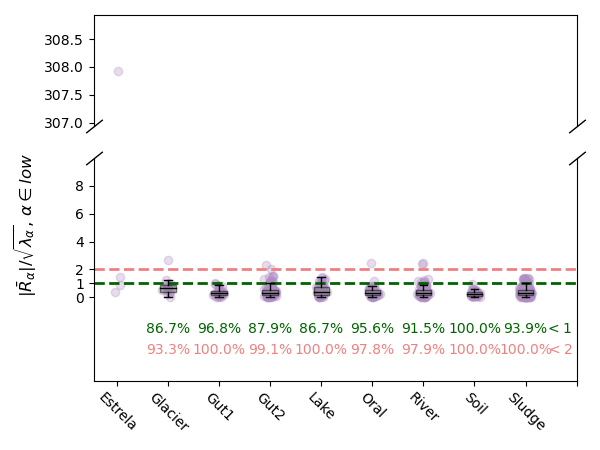

In [7]:
''' ALternative version with single-color for all datasets '''

plt.close('all')
fig,ax = plt.subplots(2,1,#sharex=True,
                     height_ratios = [1,2],
                     figsize=(6,4.5)) #make broken y-axis to show Estrela's relative abundance mode
max_value = 0
for i,dataset in enumerate(dataset_names):
    dataset = dataset_labels[i]
    means = mode_means_all_datasets[i]
    stds = mode_stds_all_datasets[i]

    factor = (np.abs(means)/stds)
    for val in factor:
        if val>max_value: max_value = val

    ''' Plot all data in lower part '''
    if i>0: #if not Estrella Dataset
        bplot = ax[1].boxplot(factor,
                          positions = [i],
                          patch_artist=True, medianprops=dict(color='k'),showfliers=False,
                           widths=0.3,
                          )
        bplot['boxes'][0].set_facecolor('tab:gray')
        bplot['boxes'][0].set_alpha(0.5)
    

        percentage_one_sigma = np.sum(factor<1)/len(factor)*100
        percentage_two_sigma = np.sum(factor<2)/len(factor)*100
    
        ax[1].text(i,-2.6,'{:.1f}%'.format(percentage_one_sigma),color='darkgreen',
               ha='center')
        ax[1].text(i,-4.1,'{:.1f}%'.format(percentage_two_sigma),color='lightcoral',
               ha='center')

    ax[1].scatter(np.random.normal(i,0.05,size=len(factor)),factor,
              color=[175/255,141/255,195/255],
              alpha=0.3,
              zorder=0,
              )

    ''' Plot all data in upper part '''
    if i>0: #if not Estrella Dataset
        bplot = ax[0].boxplot(factor,
                          positions = [i],
                          patch_artist=True, medianprops=dict(color='k'),showfliers=False,
                           widths=0.3,
                          )
        bplot['boxes'][0].set_facecolor('tab:gray')
        bplot['boxes'][0].set_alpha(0.5)
    

        percentage_one_sigma = np.sum(factor<1)/len(factor)*100
        percentage_two_sigma = np.sum(factor<2)/len(factor)*100
    
        

    ax[0].scatter(np.random.normal(i,0.05,size=len(factor)),factor,
              color=[175/255,141/255,195/255],alpha=0.3,
              zorder=0,
              label=dataset)
    

ax[1].set_ylim(bottom=-6,top=10)
ax[0].set_ylim(bottom = max_value-1,top=max_value+1)
ax[1].set_yticks([0,1,2,4,6,8]); 
ax[0].spines.bottom.set_visible(False)
ax[0].set_xticks([]); ax[0].tick_params(labelbottom=False)
ax[1].spines.top.set_visible(False)

d = .8# proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax[0].plot([0, 1], [0, 0], transform=ax[0].transAxes, **kwargs)
ax[1].plot([1,0], [1, 1], transform=ax[1].transAxes, **kwargs)


ax[1].axhline(1,linestyle='--',color='darkgreen',label=r'$<1\sigma$',linewidth=2,zorder=0)
ax[1].axhline(2,linestyle='--',color='lightcoral',label=r'$<2\sigma$',linewidth=2,zorder=0)
ax[1].text(len(dataset_names)-0.35,-2.6,r'$<1$',color='darkgreen',
               ha='center')
ax[1].text(len(dataset_names)-0.35,-4.1,r'$<2$',color='lightcoral',
               ha='center')
        # ax[0].text(i,-1.1,'{:.1f}%'.format(percentage_two_sigma),color='lightcoral',
        #        ha='center')
# ax[1].legend(loc='lower right',frameon=False)#,title='Distance to 0')
xtick_positions = np.arange(len(dataset_names)+1)
xtick_positions[0] +=0.3 #move Estrela's tick so it's centered
xtick_positions[-1] += 0.5
ax[1].set_xticks(xtick_positions)
ax[1].set_xticklabels(dataset_labels+[''],rotation=-45,ha='center')
# fig.supylabel(r'$|\bar{c}_\alpha|/\sigma_\alpha$')
# fig.supylabel(r'$\sqrt{\frac{1}{CV_\alpha}},\, \alpha \in low$')
# fig.supylabel(r'$\frac{|\bar{c}_\alpha|}{\sigma_{\alpha}},\, \alpha \in low$')
fig.supylabel(r'$|\bar{R}_\alpha|/\sqrt{\lambda_\alpha},\, \alpha \in low$')
# ax[0].legend(loc='upper right',frameon=False,title='Dataset',ncols=2)
fig.tight_layout()
fig.savefig('are_lowvar_modes_zero_modes.png',format='png',transparent=True)
fig.savefig('are_lowvar_modes_zero_modes.pdf',format='pdf',transparent=True)
fig.savefig('are_lowvar_modes_zero_modes.svg',format='svg',transparent=True)